In [1]:
import heapq
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

df = pd.read_csv("C:/Users/roysa/Downloads/bookings.csv")
# Clean: convert and drop null distances
df['Ride Distance'] = pd.to_numeric(df['Ride Distance'], errors='coerce')
df = df.dropna(subset=['Ride Distance'])
df.head(20)


,Vehicle Type,Pickup Location,Drop Location,Ride Distance
0,eBike,Palam Vihar,Jhilmil,5.73
1,Go Sedan,Shastri Nagar,Gurgaon Sector 56,5.73
2,Auto,Khandsa,Malviya Nagar,13.58
3,Premier Sedan,Central Secretariat,Inderlok,34.02
4,Bike,Ghitorni Village,Khan Market,48.21
5,Auto,AIIMS,Narsinghpur,4.85
6,Go Mini,Vaishali,Punjabi Bagh,41.24
7,Auto,Mayur Vihar,Cyber Hub,6.56
8,Go Sedan,Noida Sector 62,Noida Sector 18,5.73
9,Auto,Rohini,Adarsh Nagar,10.36


In [ ]:
# Create list of unique locations
cities = sorted(set(df["Pickup Location"]).union(set(df["Drop Location"])))
city_to_idx = {city: i for i, city in enumerate(cities)}
idx_to_city = {i: city for city, i in city_to_idx.items()}

# Initialize adjacency matrix
n = len(cities)
distance_matrix = np.full((n, n), np.inf)
np.fill_diagonal(distance_matrix, 0)


In [ ]:
# Fill adjacency matrix
# Where multiple rides exist between two locations, keep minimum distance
for _, row in df.iterrows():
    i = city_to_idx[row["Pickup Location"]]
    j = city_to_idx[row["Drop Location"]]
    d = row["Ride Distance"]
    if d < distance_matrix[i, j]:
        distance_matrix[i, j] = d
        distance_matrix[j, i] = d

# Dijkstra setup — no Q-table needed
max_steps = 200    # kept for path extraction consistency

print(f"Locations loaded : {n}")
print(f"Routes loaded    : {(distance_matrix != np.inf).sum() // 2}")


In [ ]:
def valid_actions(state):
    return [i for i in range(n) if distance_matrix[state, i] != np.inf and i != state]

def dijkstra(start_city, goal_city):
    start = city_to_idx[start_city]
    goal  = city_to_idx[goal_city]

    # dist[node] = shortest known distance from start
    dist = {start: 0}
    # prev[node] = previous node on shortest path
    prev = {start: None}
    # min-heap: (cost, node)
    heap = [(0, start)]
    visited = set()

    while heap:
        cost, u = heapq.heappop(heap)
        if u in visited:
            continue
        visited.add(u)

        if u == goal:
            break

        for v in valid_actions(u):
            new_cost = cost + distance_matrix[u, v]
            if new_cost < dist.get(v, np.inf):
                dist[v] = new_cost
                prev[v] = u
                heapq.heappush(heap, (new_cost, v))

    # Store result globally so get_optimal_path() can use it
    global _dijkstra_prev, _dijkstra_dist
    _dijkstra_prev = prev
    _dijkstra_dist = dist


In [ ]:
# Extract optimal path from Dijkstra result
def get_optimal_path(start_city, goal_city):
    start = city_to_idx[start_city]
    goal  = city_to_idx[goal_city]

    # Trace back from goal to start using prev pointers
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = _dijkstra_prev.get(node)

    path.reverse()

    # Total distance is the shortest distance found by Dijkstra
    total_distance = _dijkstra_dist.get(goal, np.inf)

    return [idx_to_city[i] for i in path], total_distance


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_network_with_path(optimal_path, total_distance, start_city, goal_city):
    # Create a graph
    G = nx.Graph()

    # Add nodes
    for city in cities:
        G.add_node(city)

    # Add edges with distances as weights
    for _, row in df.iterrows():
        G.add_edge(row["Pickup Location"], row["Drop Location"], weight=row["Ride Distance"])

    # Visualize the graph
    pos = nx.spring_layout(G, seed=170)  # for consistent layout

    plt.figure(figsize=(12, 8))

    # Draw all nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color="skyblue")

    # Highlight nodes in the optimal path
    path_nodes = optimal_path
    nx.draw_networkx_nodes(G, pos, nodelist=path_nodes, node_size=800,
                            node_color="lightgreen", edgecolors='black', linewidths=1)

    # Draw edges
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, edge_color="gray")

    # Highlight optimal path edges
    path_edges = list(zip(optimal_path, optimal_path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=2.5, edge_color="red")

    # Add labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

    plt.title(f"Network of Locations with Optimal Path from {start_city} to {goal_city}")
    plt.axis("off")
    plt.show()


In [ ]:
# Define start and goal locations
start_city = "AIIMS"
goal_city  = "Anand Vihar"

# Run Dijkstra (replaces train_q_learning)
dijkstra(start_city, goal_city)

# Get the optimal path and distance
path, dist = get_optimal_path(start_city, goal_city)

print(f"Optimal Path from {start_city} to {goal_city}: {path}")
print(f"Total Distance: {dist:.2f} km")

# Visualize the network with the optimal path and highlighted locations
visualize_network_with_path(path, dist, start_city, goal_city)


---
## Dynamic Environment — Dijkstra Agent
> Change `START_CITY` and `GOAL_CITY` to explore any route!



In [3]:
# =====================================================
#   CHANGE ONLY THESE TWO LOCATIONS
# =====================================================

START_CITY = "AIIMS"          # <-- Change me!
GOAL_CITY  = "Anand Vihar"    # <-- Change me!

import pandas as pd
_df = pd.read_csv("C:/Users/roysa/Downloads/bookings.csv")
_df['Ride Distance'] = pd.to_numeric(_df['Ride Distance'], errors='coerce')
_df = _df.dropna(subset=['Ride Distance'])
_cities = sorted(set(_df['Pickup Location']).union(set(_df['Drop Location'])))
print("Available locations:")
print(", ".join(_cities))
print(f"\nSelected:  {START_CITY}  ->  {GOAL_CITY}")


Available locations:
AIIMS, Adarsh Nagar, Akshardham, Ambience Mall, Anand Vihar, Anand Vihar ISBT, Ardee City, Arjangarh, Ashok Park Main, Ashok Vihar, Ashram, Aya Nagar, Azadpur, Badarpur, Badshahpur, Bahadurgarh, Barakhamba Road, Basai Dhankot, Bhikaji Cama Place, Bhiwadi, Botanical Garden, Central Secretariat, Chanakyapuri, Chandni Chowk, Chhatarpur, Chirag Delhi, Civil Lines Gurgaon, Connaught Place, Cyber Hub, DLF City Court, DLF Phase 3, Delhi Gate, Dilshad Garden, Dwarka Mor, Dwarka Sector 21, Faridabad Sector 15, GTB Nagar, Ghaziabad, Ghitorni, Ghitorni Village, Golf Course Road, Govindpuri, Greater Kailash, Greater Noida, Green Park, Gurgaon Railway Station, Gurgaon Sector 29, Gurgaon Sector 56, Gwal Pahari, Hauz Khas, Hauz Rani, Hero Honda Chowk, Huda City Centre, IFFCO Chowk, IGI Airport, IGNOU Road, IIT Delhi, IMT Manesar, INA Market, ITO, Inderlok, India Gate, Indirapuram, Indraprastha, Jahangirpuri, Jama Masjid, Janakpuri, Jasola, Jhilmil, Jor Bagh, Kadarpur, Kalkaji, Ka

Running Dijkstra on dynamic environment...
Route: AIIMS  ->  Anand Vihar

Dijkstra Path : AIIMS -> Anand Vihar
Distance      : 2.15 km
Event Summary : {'CLEAR': 8902, 'BLOCKAGE': 1891, 'HEAVY_CROWD': 1519, 'WEATHER': 1541, 'ROAD_WORK': 1528}


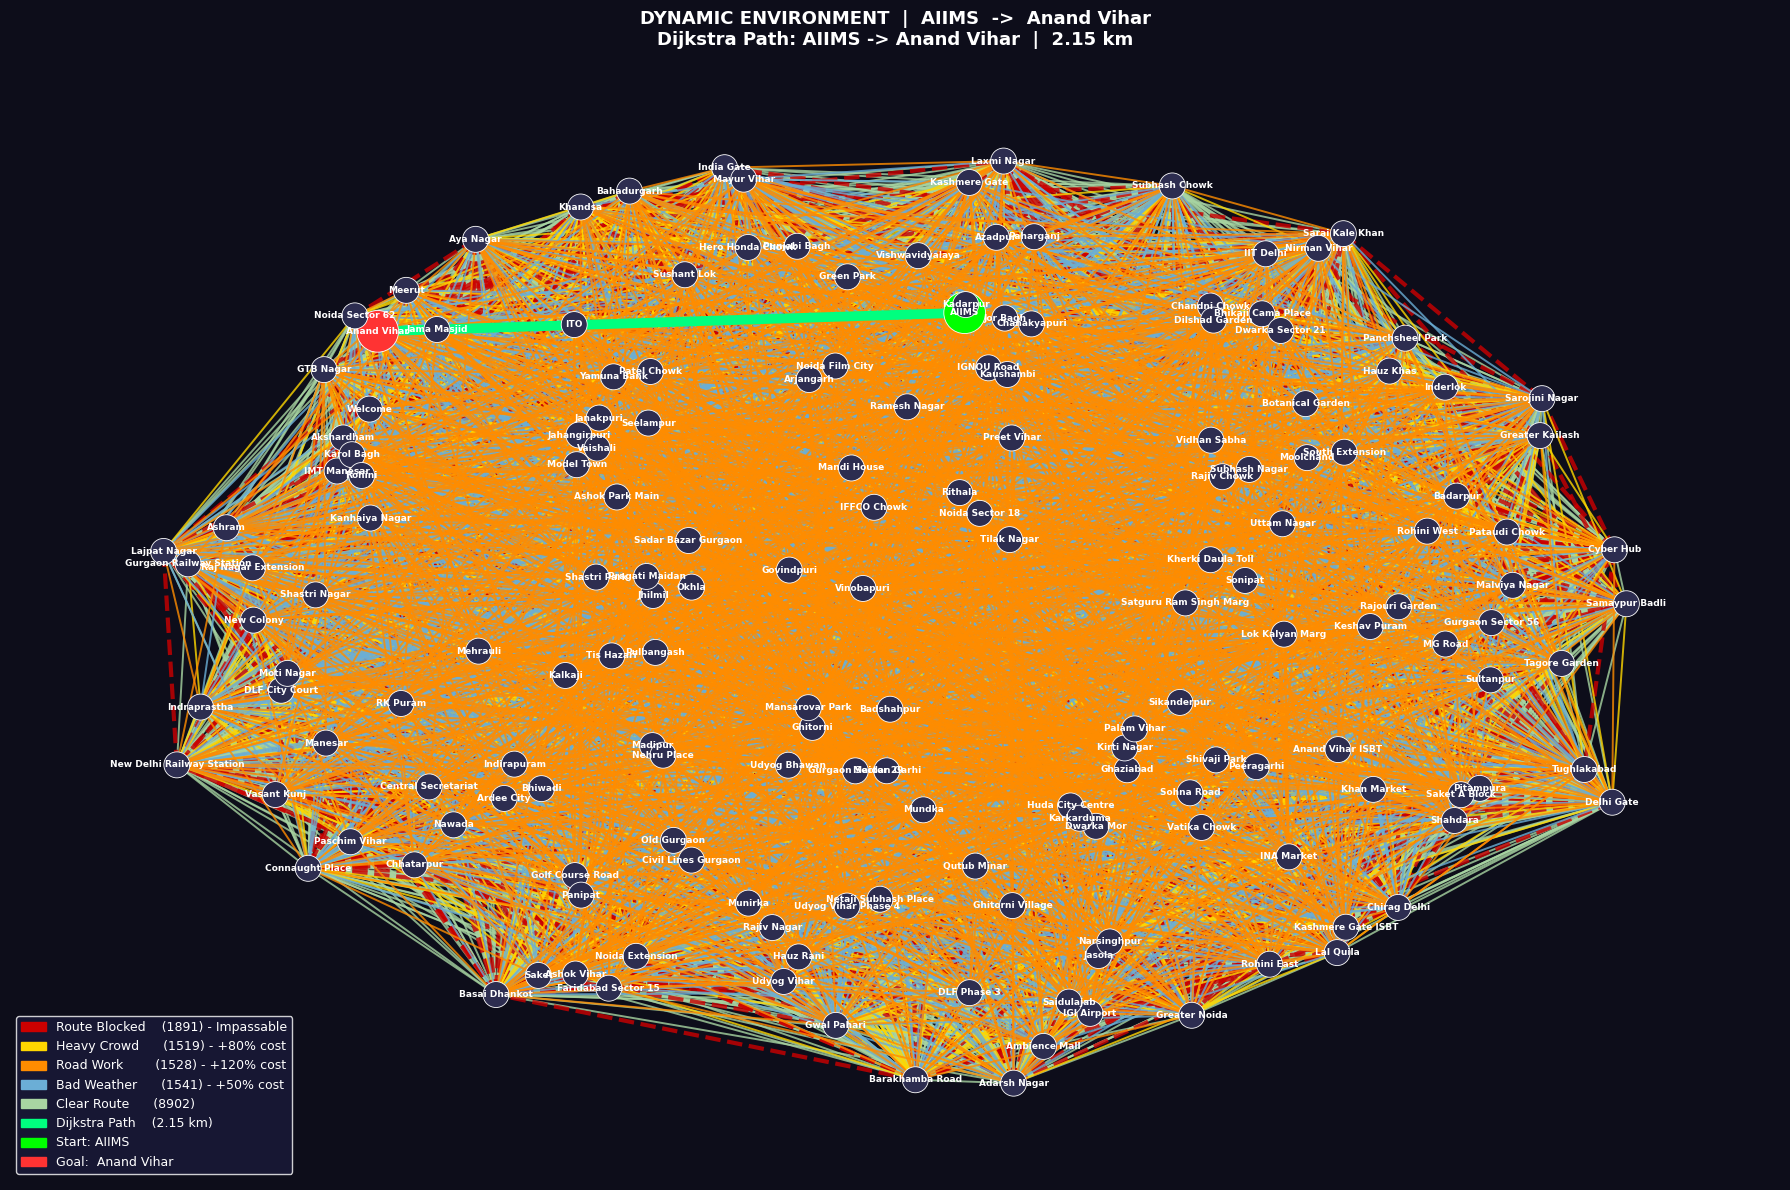

In [5]:
# =====================================================
# DIJKSTRA AGENT — DYNAMIC ENVIRONMENT
# Avoids: Blockage, Heavy Crowd, Road Work, Bad Weather
# Same logic as Q-Learning version — only algorithm replaced
# =====================================================
import heapq
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from copy import deepcopy
from collections import Counter, defaultdict

random.seed(42)
np.random.seed(42)

# -- Load data --
df          = pd.read_csv("C:/Users/roysa/Downloads/bookings.csv")
df['Ride Distance'] = pd.to_numeric(df['Ride Distance'], errors='coerce')
df          = df.dropna(subset=['Ride Distance'])
cities      = sorted(set(df['Pickup Location']).union(set(df['Drop Location'])))
city_to_idx = {city: i for i, city in enumerate(cities)}
idx_to_city = {i: city for city, i in city_to_idx.items()}
n           = len(cities)

assert START_CITY in city_to_idx, f"'{START_CITY}' not in dataset!"
assert GOAL_CITY  in city_to_idx, f"'{GOAL_CITY}' not in dataset!"
assert START_CITY != GOAL_CITY,   "Start and Goal must be different!"

# -- Build base distance matrix --
# Keep minimum distance for duplicate location pairs
base_dm = np.full((n, n), np.inf)
np.fill_diagonal(base_dm, 0)
for _, row in df.iterrows():
    i = city_to_idx[row['Pickup Location']]
    j = city_to_idx[row['Drop Location']]
    d = row['Ride Distance']
    if d < base_dm[i, j]:
        base_dm[i, j] = d
        base_dm[j, i] = d

# Unique edges list
edges = [(i,j) for i in range(n) for j in range(i+1,n) if base_dm[i,j] != np.inf]

# -- Dynamic event types (same as before) --
EVENTS = {
    'CLEAR':       {'color': '#A8D5A2', 'cost_mult': 1.0,    'label': 'Clear Route'},
    'HEAVY_CROWD': {'color': '#FFD700', 'cost_mult': 1.8,    'label': 'Heavy Crowd (+80%)'},
    'ROAD_WORK':   {'color': '#FF8C00', 'cost_mult': 2.2,    'label': 'Road Work (+120%)'},
    'WEATHER':     {'color': '#6BAED6', 'cost_mult': 1.5,    'label': 'Bad Weather (+50%)'},
    'BLOCKAGE':    {'color': '#CC0000', 'cost_mult': np.inf, 'label': 'Route Blocked'},
}

# -- Randomly assign events to routes (seed=42 for reproducibility) --
def generate_events(edges, blockage_prob=0.12, event_prob=0.30, seed=42):
    random.seed(seed)
    emap = {}
    for i, j in edges:
        r = random.random()
        if   r < blockage_prob:
            emap[(i, j)] = 'BLOCKAGE'
        elif r < blockage_prob + event_prob:
            emap[(i, j)] = random.choice(['HEAVY_CROWD', 'ROAD_WORK', 'WEATHER'])
        else:
            emap[(i, j)] = 'CLEAR'
    return emap

edge_event = generate_events(edges)
evt_counts = Counter(edge_event.values())

# -- Build dynamic cost matrix --
# Blocked routes  -> cost = inf (impassable)
# Other events    -> cost = base_distance x multiplier
dyn_dm = deepcopy(base_dm)
for (i, j), evt in edge_event.items():
    mult = EVENTS[evt]['cost_mult']
    dyn_dm[i, j] = np.inf if mult == np.inf else base_dm[i, j] * mult
    dyn_dm[j, i] = np.inf if mult == np.inf else base_dm[j, i] * mult

# -- Dijkstra on dynamic matrix --
# Replaces train_q_learning() + extract_path()
# BLOCKAGE edges are inf so Dijkstra naturally skips them
# HEAVY_CROWD / ROAD_WORK / WEATHER edges have higher cost
# so Dijkstra finds the cheapest real-world route automatically
def dijkstra(sc, gc, dm):
    """Dijkstra's algorithm on distance matrix dm.
    Returns (path_as_location_names, total_real_km).
    """
    s = city_to_idx[sc]
    g = city_to_idx[gc]

    dist    = {s: 0}
    prev    = {s: None}
    heap    = [(0, s)]
    visited = set()

    while heap:
        cost, u = heapq.heappop(heap)
        if u in visited:
            continue
        visited.add(u)
        if u == g:
            break
        for v in range(n):
            if dm[u, v] != np.inf and v != u:
                new_cost = cost + dm[u, v]
                if new_cost < dist.get(v, np.inf):
                    dist[v] = new_cost
                    prev[v] = u
                    heapq.heappush(heap, (new_cost, v))

    # Trace back path from goal to start
    path = []
    node = g
    while node is not None:
        path.append(node)
        node = prev.get(node)
    path.reverse()

    # Real km (base distances, no multipliers)
    km = sum(base_dm[path[k], path[k+1]] for k in range(len(path)-1))
    return [idx_to_city[i] for i in path], km

# -- Run Dijkstra on dynamic matrix (replaces train + extract) --
print(f"Running Dijkstra on dynamic environment...")
print(f"Route: {START_CITY}  ->  {GOAL_CITY}")
path, km = dijkstra(START_CITY, GOAL_CITY, dyn_dm)

print(f"\nDijkstra Path : {' -> '.join(path)}")
print(f"Distance      : {km:.2f} km")
print(f"Event Summary : {dict(evt_counts)}")

# =====================================================
# GRAPH — DYNAMIC ENVIRONMENT (same visualization)
# =====================================================
G = nx.Graph()
for city in cities:
    G.add_node(city)
for i, j in edges:
    G.add_edge(idx_to_city[i], idx_to_city[j], weight=base_dm[i, j])

pos  = nx.spring_layout(G, seed=170)
ped  = list(zip(path, path[1:]))
ped_set = set(map(frozenset, ped))

# Group edges by event type for fast batch drawing
edges_by_evt = defaultdict(list)
for i, j in edges:
    evt = edge_event.get((i, j), 'CLEAR')
    edges_by_evt[evt].append((idx_to_city[i], idx_to_city[j]))

fig, ax = plt.subplots(figsize=(18, 12))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')

# Draw all edges colored by event type (batch per condition)
for evt, elist in edges_by_evt.items():
    non_path = [(u, v) for u, v in elist if frozenset([u, v]) not in ped_set]
    if non_path:
        nx.draw_networkx_edges(G, pos, edgelist=non_path,
            width=3.0 if evt == 'BLOCKAGE' else 1.4,
            edge_color=EVENTS[evt]['color'],
            style='dashed' if evt == 'BLOCKAGE' else 'solid',
            alpha=0.80, ax=ax)

# Draw Dijkstra path in bright green
nx.draw_networkx_edges(
    G, pos, edgelist=ped,
    width=7, edge_color='#00FF7F', ax=ax
)

# Node colors
nc = [
    '#00FF00' if c == START_CITY else
    '#FF3333' if c == GOAL_CITY  else
    '#00BFFF' if c in path       else
    '#2d2d50'
    for c in G.nodes()
]
ns = [
    900 if (c == START_CITY or c == GOAL_CITY) else
    650 if c in path else 350
    for c in G.nodes()
]
nx.draw_networkx_nodes(G, pos, node_color=nc, node_size=ns,
                        ax=ax, edgecolors='white', linewidths=0.6)
nx.draw_networkx_labels(G, pos, font_size=6.5,
                         font_color='white', font_weight='bold', ax=ax)

ax.set_title(
    f"DYNAMIC ENVIRONMENT  |  {START_CITY}  ->  {GOAL_CITY}\n"
    f"Dijkstra Path: {' -> '.join(path)}  |  {km:.2f} km",
    fontsize=13, color='white', fontweight='bold', pad=14
)
ax.axis('off')

ax.legend(
    handles=[
        mpatches.Patch(color='#CC0000', label=f"Route Blocked    ({evt_counts.get('BLOCKAGE',    0)}) - Impassable"),
        mpatches.Patch(color='#FFD700', label=f"Heavy Crowd      ({evt_counts.get('HEAVY_CROWD', 0)}) - +80% cost"),
        mpatches.Patch(color='#FF8C00', label=f"Road Work        ({evt_counts.get('ROAD_WORK',   0)}) - +120% cost"),
        mpatches.Patch(color='#6BAED6', label=f"Bad Weather      ({evt_counts.get('WEATHER',     0)}) - +50% cost"),
        mpatches.Patch(color='#A8D5A2', label=f"Clear Route      ({evt_counts.get('CLEAR',       0)})"),
        mpatches.Patch(color='#00FF7F', label=f"Dijkstra Path    ({km:.2f} km)"),
        mpatches.Patch(color='#00FF00', label=f"Start: {START_CITY}"),
        mpatches.Patch(color='#FF3333', label=f"Goal:  {GOAL_CITY}"),
    ],
    loc='lower left', fontsize=9,
    facecolor='#1a1a3a', edgecolor='white', labelcolor='white'
)

plt.tight_layout()
plt.savefig(f"dynamic_env_{START_CITY}_to_{GOAL_CITY}.png",
            dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
